## **Análisis de Sensibilidad Global**

Este notebook implementa diferentes métodos de **Análisis de Sensibilidad Global (GSA)** utilizando la librería **SALib** en Python.  

El objetivo es evaluar la influencia de las variables de entrada sobre la variable de salida del modelo y comparar el comportamiento de distintos métodos de sensibilidad.

Los métodos analizados incluyen:

- Morris
- Sobol
- FAST
- Delta
- PAWN

A partir de estos métodos se estimará la importancia de cada variable, permitiendo identificar los factores más influyentes en el comportamiento del sistema y comparar los resultados entre metodologías.



### **1. Instalación de librerías**


In [ ]:
%pip install SALib

# <--- SALib se utiliza para realizar análisis de sensibilidad global,
# permitiendo identificar qué variables (activos, pasivos, producción, KPIs, etc.)
# tienen mayor impacto sobre un resultado financiero u operativo dentro del modelo

### **2. Importación de librerías**


In [ ]:
# Manipulación y análisis de datos
import numpy as np
import pandas as pd

# Visualización de resultados
import matplotlib.pyplot as plt

# Cálculo de distancias (útil para análisis comparativos o métricas adicionales)
from scipy.spatial.distance import cdist

# ================================
# SALib: Análisis de sensibilidad
# ================================

# Métodos de muestreo (generación de escenarios)
from SALib.sample import morris        # Método de Morris (screening)
from SALib.sample import sobol         # Muestreo Sobol (varianza global)
from SALib.sample import fast_sampler  # FAST (Fourier)

# Métodos de análisis (impacto de variables)
from SALib.analyze import morris as morris_analyze
from SALib.analyze import sobol as sobol_analyze
from SALib.analyze import delta        # Sensibilidad basada en distribución
from SALib.analyze import pawn         # Sensibilidad robusta (no paramétrica)
from SALib.analyze import fast         # Análisis FAST

### **3. Carga de datos**

In [ ]:
# Lee el archivo CSV ubicado en la ruta especificada y lo convierte en un DataFrame
# Se usa encoding="latin-1" para evitar errores con caracteres especiales (acentos, ñ, etc.)
df_original = pd.read_csv("/content/archivo_limpio.csv", encoding="latin-1")

# Crea una copia exacta del DataFrame original
# Esto permite trabajar sobre 'data' sin modificar el dataset original
data = df_original.copy()

### **4. Definir variables del modelo**

### ¿Por qué se crean variables de entrada y una variable de salida?

Para organizar mejor el modelo.  
Las variables de entrada representan los factores que pueden influir en el sistema, mientras que la variable de salida, es el resultado que queremos analizar.  

De esta forma podemos estudiar cómo cambian las entregas cuando cambian estos factores usando los métodos de análisis de sensibilidad.

[X_activos, X_pasivos, X_patrimonio, X_kpis, X_resultados, X_grupos_variables]

In [ ]:
# Definición de variables de entrada (Grupo: Activos)

# Lista de variables independientes (X) correspondientes al grupo "activos"
# Estas variables representan diferentes componentes financieros de los activos
# y serán utilizadas como entradas en el modelo de análisis
X_activos = [
    "act_total","act_circ","act_efectivo","act_clientes",
    "act_cc_fin","act_cc_no_fin","act_inventarios","act_bonos_cp",
    "act_derivados","act_otros_circ","act_no_circ","act_inv_perm",
    "act_ppye","act_doc_cob_lp","act_imp_dif","act_intangibles",
    "act_otros","act_bonos_lp","act_der_uso"
]

# Definición de la variable dependiente (Y)
# Esta variable representa la salida del modelo (producción de crudo)
# y es el objetivo sobre el cual se evaluará el impacto de las variables de entrada
variable_salida = "prod_crudo"

In [ ]:
# Definición de variables de entrada (Grupo: Pasivos)

# Lista de variables independientes (X) correspondientes al grupo "pasivos"
# Estas variables representan diferentes obligaciones financieras de corto y largo plazo,
# así como componentes relacionados con deuda, provisiones e impuestos
# Serán utilizadas como entradas para analizar su impacto en el resultado financiero
X_pasivos = [
    "pas_total","pas_cp","pas_deuda_cp","pas_prov","pas_imp_cp",
    "pas_acum","pas_derivados","pas_arr_cp","pas_lp","pas_deuda_lp",
    "pas_benef_emp","pas_prov_div","pas_otros","pas_imp_dif",
    "pas_arr_lp","pas_pat_total"
]

# Definición de la variable dependiente (Y)
# Esta variable representa el resultado integral o impacto financiero total
# (posiblemente relacionado con el estado de resultados)
# y será el objetivo del modelo para evaluar la influencia de los pasivos
variable_salida = "res_imp_total"

In [ ]:
# Definición de variables de entrada (Grupo: Patrimonio)

# Lista de variables independientes (X) correspondientes al grupo "patrimonio"
# Estas variables representan los componentes del capital contable,
# incluyendo aportaciones, reservas, utilidades retenidas y participación no controladora
# Serán utilizadas como entradas para analizar su relación con la rentabilidad de la entidad
X_patrimonio = [
    "pat_total","pat_ctrl","pat_cert_a","pat_aport_gob",
    "pat_res_legal","pat_res_acum","pat_def_acum","pat_def_ant",
    "pat_res_neta","pat_no_ctrl"
]

# Definición de la variable dependiente (Y)
# Esta variable representa la utilidad neta del periodo,
# la cual es un indicador clave de desempeño financiero
# y será el objetivo del modelo para evaluar la influencia del patrimonio
variable_salida = "res_util_neta"

In [ ]:
# =========================================
# Definición de variables de entrada (Grupo: Producción)
# =========================================

# Lista de variables independientes (X) del bloque de producción
# Estas variables representan distintos componentes operativos de producción
# (crudo, gas, petrolíferos, etc.)
# Se utilizarán para explicar su impacto sobre la utilidad neta

X_produccion = [
    "prod_hidro_tot",
    "prod_liquidos",
    "prod_crudo",
    "prod_pemex",
    "prod_socios",
    "prod_condensados",
    "prod_gas_nat",
    "prod_gas_pemex",
    "prod_gas_socios",
    "prod_gas_seco_planta",
    "prod_liq_gas",
    "prod_petroliferos",
    "prod_gas_seco",
    "prod_petroliferos_2",
    "prod_gasolina",
    "prod_combustoleo",
    "prod_diesel",
    "prod_glp",
    "prod_turbosina",
    "prod_otros",
    "prod_petroquim"
]
variable_salida = "res_util_neta"

In [ ]:
# Definición de variables de entrada (Grupo: KPIs)

# Lista de variables independientes (X) correspondientes a indicadores clave de desempeño (KPIs)
# Estas variables representan métricas financieras derivadas, como márgenes,
# proporciones de costos, carga fiscal y eficiencia operativa
# Se utilizan para analizar cómo los indicadores de desempeño impactan la rentabilidad
X_kpis = [
    "kpi_costo_ventas_ratio",
    "kpi_op_margin",
    "kpi_tax_ratio",
    "kpi_ebitda_int",
    "kpi_ebitda_ventas"
]

# Definición de la variable dependiente (Y)
# Esta variable representa la utilidad neta del periodo,
# considerada como el indicador final de desempeño financiero
# sobre el cual se evaluará el impacto de los KPIs
variable_salida = "res_util_neta"

In [ ]:
# Definición de variables de entrada (Grupo: Resultados)

# Lista de variables independientes (X) correspondientes al estado de resultados
# Estas variables representan ingresos, costos, gastos, utilidades intermedias
# y otros componentes financieros que explican la generación de resultados
# Se utilizan para analizar la dinámica interna del estado de resultados
# y su influencia sobre la utilidad neta
X_resultados = [
    "res_ing_total",
    "res_ventas_mex",
    "res_ventas_exp",
    "res_servicios",
    "res_deterioro_ppye",
    "res_costo_ventas",
    "res_util_bruta",
    "res_otros_ing",
    "res_otros_gast",
    "res_gast_dist",
    "res_gast_admin",
    "res_util_op",
    "res_costo_fin",
    "res_ing_fin",
    "res_derivados",
    "res_fx",
    "res_asociadas",
    "res_uai",
    "res_imp_total",
    "res_derechos",
    "res_imp_corr",
    "res_imp_dif",
    "res_util_neta",
    "res_ori",
    "res_actuarial",
    "res_fx_conv",
    "res_util_integral"
]

# Definición de la variable dependiente (Y)
# Esta variable representa la utilidad neta del periodo,
# considerada como el resultado final del estado de resultados
# y será el objetivo del modelo para evaluar la influencia de las variables anteriores
variable_salida = "res_util_neta"

In [ ]:
# =========================================
# Agrupación de variables por categoría
# =========================================

# Diccionario que organiza las variables independientes (X) en distintos grupos
# Cada clave representa un bloque analítico del modelo (activos, pasivos, etc.)
# y su valor es la lista de variables asociadas a ese grupo
# Esto permite estructurar el análisis de forma modular y reutilizable
grupos_variables = {
    "activos": X_activos,
    "pasivos": X_pasivos,
    "produccion": X_produccion,
    "patrimonio": X_patrimonio,
    "kpis": X_kpis,
    "resultados": X_resultados
}

# =========================================
# Definición de variables de salida por grupo / escenario
# =========================================

# Diccionario que asigna la variable dependiente (Y) a cada grupo de variables
# Esto define el objetivo del modelo según el enfoque del análisis
# y permite evaluar diferentes relaciones entre variables (escenarios analíticos)
variables_salida = {
    "activos": "prod_crudo",          # Analiza cómo los activos impactan la producción
    "pasivos": "res_imp_total",       # Evalúa la relación entre pasivos e impuestos
    "produccion": "res_util_neta",    # Mide cómo la producción influye en la utilidad
    "patrimonio": "res_util_neta",    # Analiza el impacto del patrimonio en la rentabilidad
    "kpis": "res_util_neta",          # Evalúa cómo los KPIs afectan el desempeño financiero
    "resultados": "res_util_neta"     # Analiza relaciones internas dentro del estado de resultados
}

### **5. Validacion de tipo de Datos**

In [ ]:
# =========================================
# 5. Validación y limpieza de datos
# =========================================

# Selección del grupo de análisis (en este caso: activos)
# Esto determina qué conjunto de variables independientes se utilizará
grupo = "activos"

# Obtención de las variables de entrada (X) y la variable de salida (Y)
# a partir de los diccionarios previamente definidos
variables_entrada = grupos_variables[grupo]
variable_salida = variables_salida[grupo]

# Creación de una copia del dataset original
# Se trabaja sobre 'df_modelo' para evitar modificar directamente los datos fuente
df_modelo = data.copy()

# Conversión de las variables de entrada a tipo numérico
# Los valores no convertibles (errores, texto, etc.) se transforman en NaN
df_modelo[variables_entrada] = df_modelo[variables_entrada].apply(
    pd.to_numeric,
    errors="coerce"
)

# Conversión de la variable de salida a tipo numérico
# También se manejan errores convirtiéndolos en valores nulos (NaN)
df_modelo[variable_salida] = pd.to_numeric(
    df_modelo[variable_salida],
    errors="coerce"
)

# Eliminación de registros con valores nulos en las variables del modelo
# Se asegura que el dataset final solo contenga datos completos
# tanto en las variables de entrada como en la variable de salida
df_modelo = df_modelo.dropna(subset=variables_entrada + [variable_salida])

In [ ]:
# verificacion del tipo de Dato
df_modelo.info(200)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 106 columns):
 #    Column                  Dtype  
---   ------                  -----  
 0    trimestre               object 
 1    act_total               float64
 2    act_circ                float64
 3    act_efectivo            float64
 4    act_clientes            float64
 5    act_cc_fin              float64
 6    act_cc_no_fin           float64
 7    act_inventarios         float64
 8    act_bonos_cp            float64
 9    act_derivados           float64
 10   act_otros_circ          float64
 11   act_no_circ             float64
 12   act_inv_perm            float64
 13   act_ppye                float64
 14   act_doc_cob_lp          float64
 15   act_imp_dif             float64
 16   act_intangibles         float64
 17   act_otros               float64
 18   act_bonos_lp            float64
 19   act_der_uso             float64
 20   pas_total               float64
 21   pas_cp          

## **6. Separacion de variables**

Se crea la matriz X_real con las variables de entrada del modelo.

Cada fila representa una observación del dataset y cada columna una variable de entrada.

Se crea el vector Y_real con la variable de salida.

In [ ]:
# =========================================
# 6. Separar variables (X, Y)
# =========================================

# Se crea la matriz X_real con las variables de entrada
X_real = df_modelo[variables_entrada].values.astype(float)

# Se crea el vector Y_real con la variable de salida
Y_real = df_modelo[variable_salida].values.astype(float)

# Validación del dataset final
print("Grupo seleccionado:", grupo)
print("Filas:", df_modelo.shape[0])
print("Columnas:", df_modelo.shape[1])
print("Variables de entrada:", variables_entrada)
print("Variable de salida:", variable_salida)
print("Shape X_real:", X_real.shape)
print("Shape Y_real:", Y_real.shape)

Grupo seleccionado: activos
Filas: 32
Columnas: 106
Variables de entrada: ['act_total', 'act_circ', 'act_efectivo', 'act_clientes', 'act_cc_fin', 'act_cc_no_fin', 'act_inventarios', 'act_bonos_cp', 'act_derivados', 'act_otros_circ', 'act_no_circ', 'act_inv_perm', 'act_ppye', 'act_doc_cob_lp', 'act_imp_dif', 'act_intangibles', 'act_otros', 'act_bonos_lp', 'act_der_uso']
Variable de salida: prod_crudo
Shape X_real: (32, 19)
Shape Y_real: (32,)



### **7. ¿Por qué se define el problema para libreria de Python, "SALib" ?**

En esta parte del código se crea la estructura `problem`, que es necesaria para que **SALib** pueda aplicar los métodos de análisis de sensibilidad.

Aquí se le indica a la librería:

- **num_vars**:  El número de variables de entrada que tiene el modelo.
- **names**:     Los nombres de esas variables.
- **bounds**:    El rango de valores que puede tomar cada variable (mínimo y máximo observados en los datos).

Definir estos elementos permite que SALib genere muestras dentro de esos rangos y evalúe **cómo cambian los resultados del modelo cuando varían las variables de entrada**.

In [ ]:
# =========================================
# 7. Definición del problema para SALib (dinámico por grupo)
# =========================================

# Construcción del diccionario "problem", el cual es requerido por SALib
# Este objeto define formalmente el espacio de análisis de sensibilidad:
# - número de variables de entrada
# - nombres de las variables
# - rangos (mínimo y máximo) de cada variable

problem = {
    "num_vars": len(variables_entrada),   # Cantidad total de variables independientes (X)

    "names": variables_entrada,           # Lista con los nombres de las variables

    # Definición de los límites (bounds) para cada variable
    # Se calculan dinámicamente a partir de los valores observados en el dataset limpio
    # Cada variable tendrá un rango: [mínimo, máximo]
    "bounds": [
        [
            df_modelo[var].min(),   # Valor mínimo observado en los datos
            df_modelo[var].max()    # Valor máximo observado en los datos
        ]
        for var in variables_entrada
    ]
}

# ================================
# Validación del objeto "problem"
# ================================

# Se imprime información básica para verificar que el diccionario se construyó correctamente
print("Grupo:", grupo)
print("Número de variables:", problem["num_vars"])

# Se muestran los primeros límites para validar que los rangos sean coherentes
print("Primeros límites:", problem["bounds"][:3])

Grupo: activos
Número de variables: 19
Primeros límites: [[1868504.0, 2398402.67], [294663.0, 745704.52], [36742.0, 681700.0]]



### **8. ¿Cómo y para qué se crea un modelo empírico?**

Se crea esta función para poder **estimar las variables_entrada (activos, pasivos,etc.) cuando aparecen nuevas combinaciones de variables** generadas por el análisis de sensibilidad.  

Lo que hace es comparar esos nuevos valores con los datos reales, buscar el caso más parecido y usar su valor de **variables_salida** como resultado estimado.


    Función que estima la variable de salida (Y) utilizando un enfoque empírico.

    Para cada escenario generado (X_nuevo), se busca el registro más parecido
    dentro de los datos reales (df_modelo) y se asigna su valor observado de Y.

    Parámetros:
    -----------
    X_nuevo : array (n_samples, n_variables)
        Nuevos escenarios generados (por ejemplo, con Morris)

    df_modelo : DataFrame
        Dataset limpio que contiene datos históricos reales

    variables_entrada : list
        Lista de variables independientes (X)

    variable_salida : str
        Nombre de la variable dependiente (Y)

    Retorna:
    --------
    Y_estimado : array
        Valores estimados de la variable de salida
    

In [ ]:
# =========================================
# 8. Modelo empírico (evaluador del sistema)
# =========================================

from scipy.spatial.distance import cdist
import numpy as np

def evaluar_sistema_empirico(X_nuevo, df_modelo, variables_entrada, variable_salida):
    # ================================
    # 1. Extraer datos reales (X e Y)
    # ================================

    # Matriz de variables de entrada reales
    X_real = df_modelo[variables_entrada].values

    # Vector de variable de salida real
    Y_real = df_modelo[variable_salida].values

    # ================================
    # 2. Calcular distancias
    # ================================

    # Se calcula la distancia entre cada punto nuevo (X_nuevo)
    # y todos los puntos reales (X_real)
    distancias = cdist(X_nuevo, X_real)

    # ================================
    # 3. Encontrar el vecino más cercano
    # ================================

    # Para cada escenario nuevo, se identifica el índice del caso real más parecido
    indices = np.argmin(distancias, axis=1)

    # ================================
    # 4. Asignar valor de salida
    # ================================

    # Se toma el valor de Y del caso real más cercano
    Y_estimado = Y_real[indices]

    return Y_estimado[indices]


### **9. Prueba de los métodos de análisis de sensibilidad**

En las siguientes secciones se pondrán a prueba los diferentes métodos de análisis de sensibilidad.  
Cada método generará nuevas combinaciones de las variables de entrada para evaluar cómo cambian la **variable_salida** y así identificar cuáles factores influyen más en el comportamiento del sistema.

### **10. Definicion de la muestra**

In [ ]:
# =========================================
# 10. Definición del tamaño de muestra
# =========================================

import math

# ================================
# 1. Parámetros estadísticos base
# ================================

Z = 1.96   # Nivel de confianza (95%)
p = 0.5    # Máxima variabilidad (caso más conservador)
e = 0.05   # Margen de error permitido

# ================================
# 2. Tamaño de muestra estadístico
# ================================

# Fórmula clásica de tamaño de muestra
N_est = (Z**2 * p * (1 - p)) / (e**2)

# Redondeo hacia arriba para asegurar suficiencia
N_est = math.ceil(N_est)

# ================================
# 3. Número de variables del modelo
# ================================

# Depende del grupo seleccionado dinámicamente
k = len(variables_entrada)

# ================================
# 4. Tamaño recomendado para Morris
# ================================

# Regla empírica: 10 trayectorias por variable
N_morris = 10 * k

# ================================
# 5. Selección del tamaño final
# ================================

# Se elige el mayor valor para asegurar:
# - Representatividad estadística
# - Buena exploración del espacio de variables
N = max(N_est, N_morris)

# ================================
# 6. Configuración del método Morris
# ================================

# Número de niveles (discretización del espacio)
num_levels = 4

# Trayectorias óptimas (subconjunto más eficiente)
# Se recomienda entre 30% y 50% del total
optimal_trajectories = int(N * 0.4)

# ================================
# 7. Resumen de configuración
# ================================

print("Grupo analizado:", grupo)
print("Número de variables (k):", k)
print("Tamaño de muestra estadístico (N_est):", N_est)
print("Tamaño recomendado Morris (N_morris):", N_morris)
print("Tamaño final utilizado (N):", N)
print("Niveles (num_levels):", num_levels)
print("Trayectorias óptimas:", optimal_trajectories)

Grupo analizado: activos
Número de variables (k): 19
Tamaño de muestra estadístico (N_est): 385
Tamaño recomendado Morris (N_morris): 190
Tamaño final utilizado (N): 385
Niveles (num_levels): 4
Trayectorias óptimas: 154


##**10.1. Método de MORRIS**

Es un método que descompone la varianza total de la salida en términos atribuidos a factores individuales y sus interacciones

##### **Definición de parámetros para el muestreo de Morris**

Antes de generar las combinaciones de variables, es necesario definir algunos parámetros del método de Morris.  
En particular, se establece el número de muestras (**N**) y el número de niveles (**num_levels**), que controlan cuántos escenarios del modelo se van a probar y qué tan detallada será la exploración de los valores de las variables.

In [ ]:
# =========================================================
# 10. Muestreo de parámetros con el método de Morris (OPTIMIZADO)
# =========================================================

from SALib.sample import morris

# ================================
# Ajuste de parámetros (optimización)
# ================================

# Se genera una muestra de combinaciones de las variables de entrada.
# Esta muestra permite probar diferentes escenarios del modelo y observar cómo cambia el resultado cuando varían las variables.
# Con estos escenarios el método de Morris puede medir qué variables influyen más en las ENTREGAS.

N = 150
# Se reduce el número de trayectorias iniciales para mejorar el tiempo de ejecución.
# Morris no requiere tamaños grandes como en estadística clásica.
# Este valor permite un buen balance entre exploración y eficiencia.

num_levels = 4
# Se mantiene en 4 niveles, ya que es un estándar adecuado para capturar variabilidad
# sin incrementar demasiado el costo computacional.

optimal_trajectories = 10
# Se reduce el número de trayectorias óptimas.
# Esto evita el costo computacional elevado de la optimización combinatoria,
# manteniendo suficiente diversidad en el espacio de parámetros.

# ================================
# Generación de escenarios
# ================================

X_morris = morris.sample(

    problem,
    # Contiene:
    # - Número de variables
    # - Nombres
    # - Rangos de cada variable

    N = N,
    # Número de trayectorias optimizado

    num_levels = num_levels,
    # Resolución del espacio de búsqueda

    optimal_trajectories = optimal_trajectories
    # Selección de trayectorias más representativas (optimizado)
)

# ================================
# Información del muestreo generado
# ================================

print("Grupo analizado:", grupo)
print("Dimensión de la matriz X_morris:", X_morris.shape)
print("Número de escenarios generados:", X_morris.shape[0])
print("Número de variables:", X_morris.shape[1])

X_morris[:5]

Grupo analizado: activos
Dimensión de la matriz X_morris: (200, 19)
Número de escenarios generados: 200
Número de variables: 19


array([[1868504.        ,  745704.52      ,  251728.        ,
          11093.        ,       0.        ,   56609.33333333,
              0.        ,       0.        ,   14217.66666667,
           4130.66666667, 1314733.33333333,    7725.66666667,
        1198630.        ,  663333.33333333,       0.        ,
         508666.66666667,  476200.        ,  717500.        ,
          68050.        ],
       [1868504.        ,  745704.52      ,  681700.        ,
          11093.        ,       0.        ,   56609.33333333,
              0.        ,       0.        ,   14217.66666667,
           4130.66666667, 1314733.33333333,    7725.66666667,
        1198630.        ,  663333.33333333,       0.        ,
         508666.66666667,  476200.        ,  717500.        ,
          68050.        ],
       [1868504.        ,  745704.52      ,  681700.        ,
          11093.        ,       0.        ,   56609.33333333,
              0.        ,       0.        ,   42653.        ,
           4130.


  -  **Cada fila:** un escenario de prueba con todas las variables  
  -  **Cada columna:**  una variable de entrada distinta
  -  El método Morris cambiará una variable a la vez por fila para ver su impacto  


In [ ]:
# =========================================================
# Evaluación del modelo con las muestras generadas
# =========================================================

# Se evalúa el modelo empírico utilizando los escenarios
# generados con el método de Morris (X_morris).
# Para cada escenario, se busca el caso real más parecido
# dentro de los datos históricos y se asigna su resultado.

Y_morris = evaluar_sistema_empirico(

    X_morris,
    # Matriz de escenarios generados con Morris.
    # Cada fila representa una combinación distinta de variables
    # (por ejemplo: activos, pasivos, etc.)

    df_modelo,
    # Base de datos real ya limpia.
    # Contiene los valores históricos observados del sistema.

    variables_entrada,
    # Lista de variables independientes (X)
    # que explican el comportamiento del sistema.

    variable_salida
    # Variable objetivo (Y), por ejemplo:
    # producción, utilidad, impuestos, etc.
)


# ================================
# Información de salida
# ================================

print("Número de resultados generados:", len(Y_morris))
Y_morris

Número de resultados generados: 200


array([1690., 1630., 1630., 1630., 1630., 1630., 1690., 1690., 1630.,
       1630., 1690., 1690., 1690., 1690., 1690., 1690., 1690., 1690.,
       1690., 1690., 1710., 1690., 1700., 1690., 1690., 1700., 1710.,
       1710., 1700., 1700., 1700., 1700., 1700., 1700., 1700., 1630.,
       1630., 1630., 1630., 1630.,    0.,    0.,    0.,    0.,    0.,
       1630., 1630., 1630., 1630., 1630., 1630., 1630., 1630., 1630.,
       1630., 1630., 1630., 1630., 1630., 1630., 1690., 1690., 1690.,
       1690., 1690., 1690., 1690., 1690., 1690., 1690., 1710., 1710.,
       1710., 1710., 1710., 1710., 1710., 1710.,    0.,    0.,    0.,
          0.,    0.,    0.,    0.,    0., 1690., 1690., 1690., 1630.,
       1710., 1690., 1630., 1630., 1630., 1630., 1630., 1630., 1630.,
       1630., 1690., 1700., 1700., 1700., 1690., 1690., 1690., 1690.,
       1690., 1690., 1690., 1690., 1690., 1690., 1690., 1690., 1690.,
       1690., 1690., 1690., 1700., 1700., 1700., 1700., 1700., 1700.,
       1700., 1690.,

In [ ]:
# =========================================================
# 11. Análisis de sensibilidad con el método de Morris
# =========================================================

# Se realiza el análisis de sensibilidad global utilizando
# el método de Morris, el cual permite identificar qué variables
# tienen mayor influencia sobre la variable objetivo del modelo.

Si_morris = morris_analyze.analyze(

    problem,
    # Definición formal del problema de sensibilidad.
    # Contiene:
    # - Número de variables (k)
    # - Nombres de las variables
    # - Rangos de variación de cada variable
    # Esto permite interpretar correctamente los efectos calculados.

    X_morris,
    # Matriz de escenarios generados con el muestreo de Morris.
    # Cada fila representa una combinación distinta de valores
    # de las variables de entrada (experimentos simulados).

    Y_morris,
    # Resultados del modelo para cada escenario de X_morris.
    # Es la respuesta del sistema ante cada combinación de variables.

    print_to_console=True
    # Muestra directamente en consola los resultados principales
    # del análisis de sensibilidad (μ, μ*, σ).
)

# ================================
# Acceso a resultados
# ================================

mu = Si_morris['mu']          # Efecto promedio (puede cancelarse)
mu_star = Si_morris['mu_star']# Efecto absoluto promedio (IMPORTANTE)
sigma = Si_morris['sigma']    # Variabilidad (interacciones / no linealidad)

# ================================
# Resumen rápido
# ================================

print("\nResumen de sensibilidad:")
for i, var in enumerate(problem['names']):
    print(f"{var}: mu*={mu_star[i]:.4f}, sigma={sigma[i]:.4f}")

                    mu  mu_star        sigma  mu_star_conf
act_total          1.5      1.5     4.743416      2.632222
act_circ          12.0     12.0    37.947332     24.303553
act_efectivo     -25.5     28.5    44.749302     25.356755
act_clientes     247.5    247.5   772.147978    436.074585
act_cc_fin        -1.5      1.5     4.743416      2.157377
act_cc_no_fin      0.0      0.0     0.000000      0.000000
act_inventarios   -6.0     12.0    30.983867     15.471644
act_bonos_cp       0.0      0.0     0.000000      0.000000
act_derivados      0.0      0.0     0.000000      0.000000
act_otros_circ     0.0      0.0     0.000000      0.000000
act_no_circ     -505.5    508.5  1046.543119    596.216530
act_inv_perm       0.0      0.0     0.000000      0.000000
act_ppye           6.0      6.0    12.649111      8.047361
act_doc_cob_lp    -1.5      1.5     4.743416      2.984158
act_imp_dif     -250.5    256.5   802.746847    486.558597
act_intangibles  246.0    267.0   815.297492    490.1442

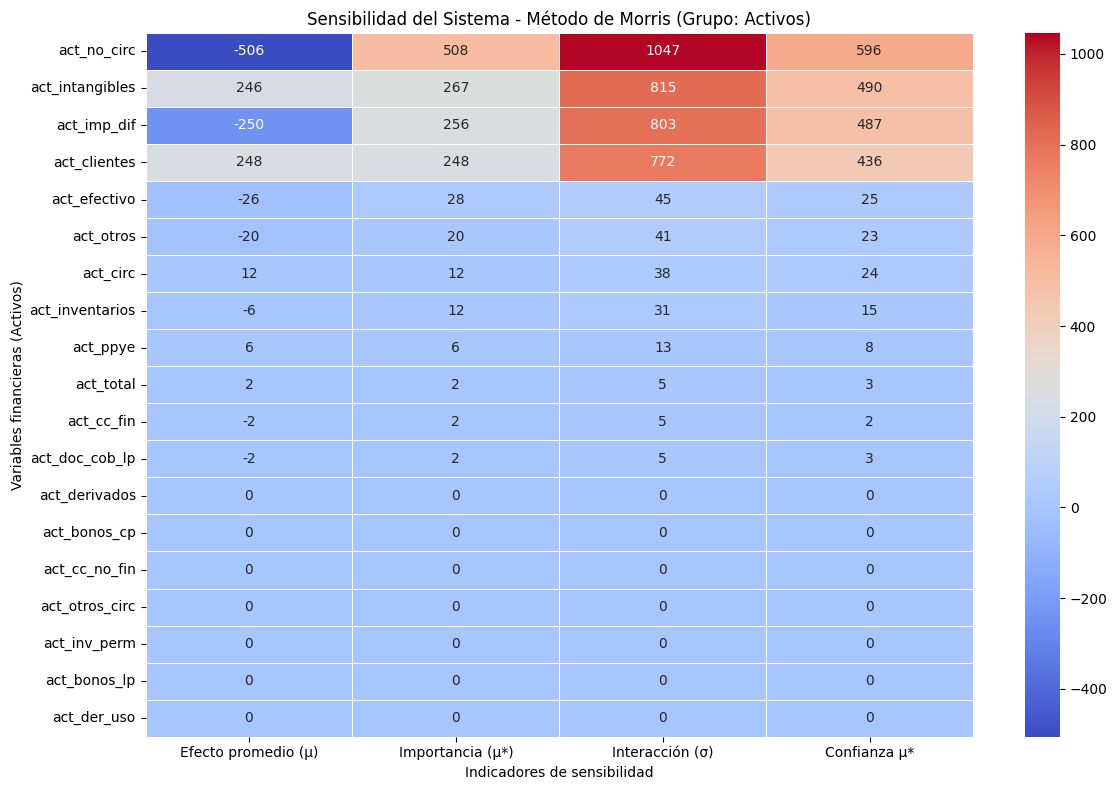

In [ ]:
# =========================================================
# 12. Visualización de resultados - Método de Morris (Activos)
# =========================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ================================
# Construcción automática del DataFrame
# ================================

df_morris = pd.DataFrame({
    "Efecto promedio (μ)": Si_morris['mu'],
    "Importancia (μ*)": Si_morris['mu_star'],
    "Interacción (σ)": Si_morris['sigma'],
    "Confianza μ*": Si_morris['mu_star_conf']
}, index=problem['names'])

# ================================
# Ordenar variables por importancia
# ================================

df_morris = df_morris.sort_values(by="Importancia (μ*)", ascending=False)

# ================================
# Heatmap (interpretación visual)
# ================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df_morris,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".0f"
)

plt.title("Sensibilidad del Sistema - Método de Morris (Grupo: Activos)")
plt.ylabel("Variables financieras (Activos)")
plt.xlabel("Indicadores de sensibilidad")

plt.tight_layout()
plt.show()

## 📊 Interpretación de resultados – Método de Morris (Grupo: Activos)

El análisis de sensibilidad global mediante el método de Morris permitió identificar las variables más influyentes del grupo de activos sobre la producción de crudo.

Uno de los hallazgos más relevantes es el comportamiento de la variable **`act_imp_dif` (impuestos diferidos)**, la cual presenta:

- Alta importancia (μ\* elevado)
- Efecto promedio significativo (μ distinto de cero)
- Posible interacción con otras variables del sistema (σ relevante)

### 🧠 Interpretación

La variable `act_imp_dif` no representa directamente flujos operativos como producción o inversión física, sino que corresponde a un componente contable asociado a **impuestos diferidos**, es decir, beneficios o cargas fiscales que se reconocen en el tiempo.

El hecho de que esta variable tenga un impacto significativo en el modelo sugiere que:

- La **estructura fiscal de la empresa** influye de manera importante en el desempeño operativo medido.
- Existen **efectos indirectos** entre variables contables y productivas.
- Parte del comportamiento de la producción podría estar asociado a **decisiones financieras y fiscales**, no únicamente a capacidad operativa.


### **Significado de los resultados**

- **mu**  
  - Efecto promedio de la variable.
  - Si es **positivo**, significa que al aumentar la variable el resultado del modelo tiende a **aumentar**.
  - Si es **negativo**, significa que al aumentar la variable el resultado del modelo tiende a **disminuir**.

- **mu_star**  
  - Efecto total del impacto de la variable.
  - Se calcula usando valores absolutos, por lo que **no indica dirección (positivo o negativo)**, sino **qué tan importante es la variable en el modelo**.

- **sigma**  
  - Desviación estándar o variabilidad del efecto de la variable.
  - Cuanto mayor sea, más **interacciones con otras variables o comportamientos no lineales** puede tener la variable dentro del modelo.

- **mu_star_conf**  
  - Intervalo de confianza asociado a la estimación de `mu_star`.
  - Valores más altos indican mayor **incertidumbre en la estimación**, mientras que valores más bajos sugieren que la influencia de la variable está **estimada con mayor estabilidad**.

### **2) Método Sobol**
Permite identificar qué variables y combinaciones de variables tienen mayor impacto sobre el resultado del modelo.

Es útil para modelos complejos donde los efectos no son lineales ni independientes.

###**Muestreo en el método Sobol**
Se usa el método Sobol para generar muchos escenarios posibles del sistema variando las variables dentro de sus rangos.

X_sobol = sobol.sample(problem, N=385, calc_second_order=True)

##**¿Por qué se hace esto?**
Porque queremos ver cómo cambia el resultado del modelo cuando cambian las variables.
En lugar de probar pocos casos, Sobol genera muchas combinaciones bien distribuidas en el espacio de posibles valores.

##**¿Cómo se generan los escenarios?**
El algoritmo toma los rangos de cada variable definidos en problem.
Genera puntos entre 0 y 1 usando una secuencia Sobol (no es completamente aleatoria, está diseñada para cubrir mejor el espacio).
Esos puntos se transforman al rango real de cada variable.
Así se crean muchos escenarios del sistema, donde:

cada fila = un escenario o evento
cada columna = una variable del modelo
Después el modelo se evalúa en cada escenario para analizar qué variables influyen más en el resultado.

In [ ]:
# =========================================
# 1. Definición del problema (Sobol)
# =========================================

# Se importa numpy para manejo de estructuras numéricas
# (aunque en este bloque no se usa directamente, es estándar en el pipeline)
import numpy as np


# =========================================
# Selección de variables del grupo
# =========================================

# Se obtienen las variables de entrada (X) correspondientes al grupo seleccionado
# (por ejemplo: activos, pasivos, producción, etc.)
#
# 'grupo' actúa como parámetro dinámico que permite reutilizar el código
# para distintos escenarios de análisis

variables_entrada = grupos_variables[grupo]


# =========================================
# Número de variables del modelo
# =========================================

# Se calcula el número total de variables independientes
# Este valor es requerido por SALib para estructurar el problema
# de análisis de sensibilidad

num_vars = len(variables_entrada)


# =========================================
# Definición de límites (bounds)
# =========================================

# Se construyen los límites inferior y superior de cada variable
# utilizando los valores mínimo y máximo observados en el dataset limpio (df_modelo)
#
# Estos límites definen el rango dentro del cual Sobol generará
# combinaciones de valores para evaluar el modelo

bounds = []

for var in variables_entrada:

    # Valor mínimo observado en los datos
    min_val = df_modelo[var].min()

    # Valor máximo observado en los datos
    max_val = df_modelo[var].max()

    # Se agrega el rango [min, max] a la lista de límites
    bounds.append([min_val, max_val])


# =========================================
# Definición del problema para SALib
# =========================================

# Se construye el diccionario 'problem', que es la estructura
# requerida por SALib para ejecutar el análisis de sensibilidad Sobol
#
# Componentes:
# - num_vars: número de variables independientes
# - names: nombres de las variables (para trazabilidad e interpretación)
# - bounds: rangos de variación de cada variable

problem = {
    "num_vars": num_vars,
    "names": variables_entrada,
    "bounds": bounds
}


# =========================================
# Validación del problema
# =========================================

# Se imprime información clave para verificar que el problema
# está correctamente definido antes de realizar el muestreo Sobol

print("Grupo seleccionado:", grupo)
print("Número de variables:", num_vars)
print("Variables:", variables_entrada)
print("Primeros límites:", bounds[:3])  # muestra solo los primeros para inspección rápida

Grupo seleccionado: activos
Número de variables: 19
Variables: ['act_total', 'act_circ', 'act_efectivo', 'act_clientes', 'act_cc_fin', 'act_cc_no_fin', 'act_inventarios', 'act_bonos_cp', 'act_derivados', 'act_otros_circ', 'act_no_circ', 'act_inv_perm', 'act_ppye', 'act_doc_cob_lp', 'act_imp_dif', 'act_intangibles', 'act_otros', 'act_bonos_lp', 'act_der_uso']
Primeros límites: [[1868504.0, 2398402.67], [294663.0, 745704.52], [36742.0, 681700.0]]


### **Evaluación del modelo con escenarios Sobol**
Después de generar los escenarios con Sobol (X_sobol), se evalúa el modelo para obtener el resultado del sistema en cada caso.

**¿Qué representa Y_sobol?**
Y_sobol es un vector donde:

cada posición corresponde a un escenario generado por Sobol
el valor es el resultado del sistema para ese escenario
**Interpretación**
Muchos valores iguales a 0 indican que en varios escenarios el sistema no genera producción o resultado.

Esto ocurre cuando la combinación de variables (producción, inventario, autoconsumo, etc.) no permite que el sistema opere o genere salida.

Este vector es la base para calcular la sensibilidad de cada variable en el modelo.

In [ ]:
# =========================================
# PIPELINE COMPLETO: ANÁLISIS SOBOL
# =========================================

import numpy as np
import pandas as pd

# =========================================
# 1. Selección del grupo de análisis
# =========================================

# Define aquí el grupo que quieres analizar:
# "activos", "pasivos", "produccion", "patrimonio", "kpis", "resultados"

grupo = "produccion"

# Variables de entrada (X) y salida (Y)
variables_entrada = grupos_variables[grupo]
variable_salida = variables_salida[grupo]


# =========================================
# 2. Preparación de datos (dataset limpio)
# =========================================

# Se crea una copia del dataset original
df_modelo = data.copy()

# Conversión a numérico (manejo de errores → NaN)
df_modelo[variables_entrada] = df_modelo[variables_entrada].apply(
    pd.to_numeric,
    errors="coerce"
)

df_modelo[variable_salida] = pd.to_numeric(
    df_modelo[variable_salida],
    errors="coerce"
)

# Eliminación de valores nulos
df_modelo = df_modelo.dropna(subset=variables_entrada + [variable_salida])


# =========================================
# 3. Separación de variables (X, Y)
# =========================================

# Matriz de entrada (features)
X_real = df_modelo[variables_entrada].values.astype(float)

# Vector de salida (target)
Y_real = df_modelo[variable_salida].values.astype(float)

print("Shape X_real:", X_real.shape)
print("Shape Y_real:", Y_real.shape)


# =========================================
# 4. Definición del problema (Sobol)
# =========================================

# Número de variables
num_vars = len(variables_entrada)

# Límites (bounds) usando datos reales
bounds = []

for var in variables_entrada:
    min_val = df_modelo[var].min()
    max_val = df_modelo[var].max()
    bounds.append([min_val, max_val])

# Estructura requerida por SALib
problem = {
    "num_vars": num_vars,
    "names": variables_entrada,
    "bounds": bounds
}

print("Número de variables:", num_vars)


# =========================================
# 5. Muestreo Sobol
# =========================================

from SALib.sample import sobol

# Generación de muestras del espacio de variables
X_sobol = sobol.sample(
    problem,
    N=385,
    calc_second_order=True
)

print("Shape X_sobol:", X_sobol.shape)


# =========================================
# 6. Definición del modelo empírico
# =========================================

def evaluar_sistema_empirico(X_sobol, X_real, Y_real):
    """
    Entrena un modelo con datos reales y evalúa sobre muestras Sobol.
    """

    from sklearn.ensemble import RandomForestRegressor

    # Modelo no lineal robusto
    modelo = RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )

    # Entrenamiento
    modelo.fit(X_real, Y_real)

    # Predicción sobre Sobol
    Y_sobol = modelo.predict(X_sobol)

    return Y_sobol


# =========================================
# 7. Evaluación del modelo
# =========================================

Y_sobol = evaluar_sistema_empirico(
    X_sobol,
    X_real,
    Y_real
)

print("Shape Y_sobol:", Y_sobol.shape)


# =========================================
# 8. Análisis de sensibilidad Sobol
# =========================================

from SALib.analyze import sobol

Si = sobol.analyze(
    problem,
    Y_sobol,
    calc_second_order=True
)

# =========================================
# 9. Resultados
# =========================================

print("\n--- RESULTADOS SOBOL ---")
print("S1 (efecto individual):")
print(Si["S1"])

print("\nST (efecto total):")
print(Si["ST"])

Shape X_real: (32, 21)
Shape Y_real: (32,)
Número de variables: 21
Shape X_sobol: (16940, 21)


/usr/local/lib/python3.12/dist-packages/SALib/sample/sobol.py:136: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  base_sequence = qrng.random(N)


Shape Y_sobol: (16940,)

--- RESULTADOS SOBOL ---
S1 (efecto individual):
[ 0.07331032  0.00384603 -0.00026596  0.10330533  0.00582155  0.07072611
 -0.00321429  0.00455069  0.11507346  0.00901209  0.00371191  0.03318578
  0.04492763  0.00274447  0.01425228  0.20826807  0.00765237 -0.0017523
  0.01789418  0.10069056  0.11046582]

ST (efecto total):
[0.08621285 0.0042417  0.00835124 0.12406428 0.00479055 0.08993213
 0.0046399  0.00595632 0.10600877 0.00792527 0.00160826 0.03946646
 0.06388998 0.00611519 0.00931898 0.24705356 0.00561035 0.02441931
 0.02409561 0.08600266 0.14143955]



###  Interpretación del Análisis de Sensibilidad de Sobol

En este análisis se evaluó la influencia de las variables del grupo **{grupo}** sobre la variable de salida **{variable_salida}**, utilizando simulaciones generadas con muestreo de Sobol (`X_sobol`) y evaluadas mediante un modelo empírico (`Y_sobol`).

---

###  Fundamento del método

El método de Sobol descompone la **varianza total del modelo**:

:contentReference[oaicite:0]{index=0}

Donde:

- \(V_i\): contribución individual de cada variable  
- \(V_{ij}\): interacción entre variables  
- La suma total explica la variabilidad de la salida del modelo  

---

###  Métricas obtenidas (`Si`)

Los resultados del análisis se encuentran en el objeto:

```python
Si

In [ ]:
# =========================================
# 8. Análisis de sensibilidad Sobol
# =========================================

# Import correcto del analizador
from SALib.analyze import sobol as sobol_analyze

# Ejecución del análisis
Si_sobol = sobol_analyze.analyze(
    problem,            # Definición del problema (variables y bounds)
    Y_sobol,            # Salida del modelo evaluada con Sobol
    calc_second_order=True,   # Incluye interacciones (S2)
    print_to_console=True     # Muestra resultados en consola
)

# =========================================
# 9. Acceso a resultados
# =========================================

# Efecto de primer orden (impacto directo)
S1 = Si_sobol["S1"]

# Efecto total (impacto total incluyendo interacciones)
ST = Si_sobol["ST"]

# Interacciones entre variables
S2 = Si_sobol["S2"]

print("\n--- RESUMEN ---")
print("S1:", S1)
print("ST:", ST)

                            ST   ST_conf
prod_hidro_tot        0.086213  0.014654
prod_liquidos         0.004242  0.000837
prod_crudo            0.008351  0.002686
prod_pemex            0.124064  0.021034
prod_socios           0.004791  0.001278
prod_condensados      0.089932  0.019567
prod_gas_nat          0.004640  0.000903
prod_gas_pemex        0.005956  0.002295
prod_gas_socios       0.106009  0.019831
prod_gas_seco_planta  0.007925  0.001799
prod_liq_gas          0.001608  0.000384
prod_petroliferos     0.039466  0.006619
prod_gas_seco         0.063890  0.011071
prod_petroliferos_2   0.006115  0.001594
prod_gasolina         0.009319  0.001865
prod_combustoleo      0.247054  0.050286
prod_diesel           0.005610  0.001230
prod_glp              0.024419  0.005816
prod_turbosina        0.024096  0.007849
prod_otros            0.086003  0.016722
prod_petroquim        0.141440  0.022862
                            S1   S1_conf
prod_hidro_tot        0.073310  0.036250
prod_liquidos   

In [ ]:
# =========================================
# 10. Construcción del DataFrame de resultados Sobol
# =========================================

# Validación (muy importante)
if len(variables_entrada) != len(Si_sobol["S1"]):
    raise ValueError("Las dimensiones no coinciden entre variables y resultados Sobol")

# Construcción del DataFrame
df_sobol = pd.DataFrame({
    "Variable": variables_entrada,
    "Sobol_S1": Si_sobol["S1"],
    "Sobol_ST": Si_sobol["ST"]
})

# =========================================
# 11. Limpieza de resultados
# =========================================

# Valores negativos → se interpretan como 0 (ruido numérico)
df_sobol["Sobol_S1"] = df_sobol["Sobol_S1"].clip(lower=0)
df_sobol["Sobol_ST"] = df_sobol["Sobol_ST"].clip(lower=0)

# =========================================
# 12. Ranking de importancia
# =========================================

# Ordenar por impacto total
df_sobol = df_sobol.sort_values(by="Sobol_ST", ascending=False)

# Crear ranking
df_sobol["Ranking"] = range(1, len(df_sobol) + 1)

# =========================================
# 13. Visualización
# =========================================

df_sobol.reset_index(drop=True, inplace=True)

print("\n--- TOP VARIABLES (SOBOL) ---")
display(df_sobol.head(10))


--- TOP VARIABLES (SOBOL) ---


,Variable,Sobol_S1,Sobol_ST,Ranking
0,prod_combustoleo,0.208268,0.247054,1
1,prod_petroquim,0.110466,0.141440,2
2,prod_pemex,0.103305,0.124064,3
3,prod_gas_socios,0.115073,0.106009,4
4,prod_condensados,0.070726,0.089932,5
5,prod_hidro_tot,0.073310,0.086213,6
6,prod_otros,0.100691,0.086003,7
7,prod_gas_seco,0.044928,0.063890,8
8,prod_petroliferos,0.033186,0.039466,9
9,prod_glp,0.000000,0.024419,10


### **DELTA**

Evalúa **cómo cambia la salida del modelo ante pequeños cambios en cada factor** (derivada local).  
  - Se **normaliza el efecto** multiplicando por la variabilidad de la variable de entrada y dividiendo por la variabilidad de la salida.  
  - El resultado indica **la importancia relativa de cada factor** sobre el comportamiento del modelo.  

### **Muestreo para Delta**

- `X_delta = sobol.sample(...)` genera **muestras de las variables de entrada** usando la secuencia de Sobol.  
- `calc_second_order=False` significa que solo se consideran **efectos individuales**, no interacciones. .

### **Muestreo de variables de entrada (Sobol)**

- `X_sobol = sobol.sample(problem, N=385, calc_second_order=True)` genera **muestras sintéticas de las variables de entrada** definidas en `variables_entrada`, utilizando la secuencia de Sobol.

- Estas muestras se construyen a partir de los **límites reales (`bounds`) extraídos del dataset (`df_modelo`)**, lo que garantiza que las simulaciones sean consistentes con el comportamiento observado en los datos.

- `calc_second_order=True` indica que el muestreo está diseñado para permitir el cálculo de:
  - **Efectos individuales (S1)**  
  - **Efectos totales (ST)**  
  - **Interacciones entre variables (S2)**  

- El resultado `X_sobol` es una matriz donde:
  - Cada fila representa un **escenario simulado del sistema**  
  - Cada columna corresponde a una variable del grupo **{grupo}**

---

### **Nota importante**

Si se utilizara `calc_second_order=False`:

- Solo se podrían analizar **efectos individuales (S1 y ST)**  
- **No se podrían estimar interacciones (S2)**  

En este análisis se decidió incluir interacciones, ya que el sistema presenta **dependencias estructurales entre variables** (por ejemplo, producción, importaciones y refinación).

In [ ]:
# =========================================
# 5. Muestreo Sobol (configuración tipo Delta)
# =========================================

from SALib.sample import sobol
import pandas as pd
import numpy as np

# ⚠️ IMPORTANTE:
# Sobol funciona mejor cuando N es potencia de 2
# Opciones recomendadas: 256, 512, 1024
N = 512

# Generación de muestras
X_delta = sobol.sample(
    problem,                 # Definición del problema (variables y límites)
    N=N,                     # Número de muestras (potencia de 2)
    calc_second_order=False  # Solo efectos individuales (sin interacciones)
)

# =========================================
# 6. Conversión a DataFrame (MEJOR VISUALIZACIÓN)
# =========================================

df_X_delta = pd.DataFrame(
    X_delta,
    columns=problem["names"]  # Nombres reales de tus variables
)

# =========================================
# 7. Validación del muestreo
# =========================================

print("Shape X_delta:", X_delta.shape)

# Mostrar primeras filas (mucho más claro que array)
display(df_X_delta.head())

Shape X_delta: (11776, 21)


,prod_hidro_tot,prod_liquidos,prod_crudo,prod_pemex,prod_socios,prod_condensados,prod_gas_nat,prod_gas_pemex,prod_gas_socios,prod_gas_seco_planta,...,prod_petroliferos,prod_gas_seco,prod_petroliferos_2,prod_gasolina,prod_combustoleo,prod_diesel,prod_glp,prod_turbosina,prod_otros,prod_petroquim
0,2460.457495,1662.052796,1676.212024,2050.599432,52.422353,5.453746,4608.723651,340.307597,92.002085,1721.608878,...,717.930864,632.617562,294.992512,341.791754,73.012531,194.685123,73.778163,86.722152,32.484855,403.590772
1,2378.276945,1662.052796,1676.212024,2050.599432,52.422353,5.453746,4608.723651,340.307597,92.002085,1721.608878,...,717.930864,632.617562,294.992512,341.791754,73.012531,194.685123,73.778163,86.722152,32.484855,403.590772
2,2460.457495,1653.844993,1676.212024,2050.599432,52.422353,5.453746,4608.723651,340.307597,92.002085,1721.608878,...,717.930864,632.617562,294.992512,341.791754,73.012531,194.685123,73.778163,86.722152,32.484855,403.590772
3,2460.457495,1662.052796,1773.974807,2050.599432,52.422353,5.453746,4608.723651,340.307597,92.002085,1721.608878,...,717.930864,632.617562,294.992512,341.791754,73.012531,194.685123,73.778163,86.722152,32.484855,403.590772
4,2460.457495,1662.052796,1676.212024,3033.434703,52.422353,5.453746,4608.723651,340.307597,92.002085,1721.608878,...,717.930864,632.617562,294.992512,341.791754,73.012531,194.685123,73.778163,86.722152,32.484855,403.590772


In [ ]:
# =========================================
# 8. Evaluación del sistema (muestras Delta)
# =========================================

# Validación previa (evita errores silenciosos)
if 'X_delta' not in globals():
    raise ValueError("X_delta no está definido. Ejecuta primero el muestreo.")

if X_real.shape[1] != X_delta.shape[1]:
    raise ValueError("Las dimensiones de X_real y X_delta no coinciden.")

# Evaluación del modelo empírico sobre las muestras Delta
Y_delta = evaluar_sistema_empirico(
    X_delta,   # Escenarios simulados generados con Sobol (sin interacciones)
    X_real,    # Datos reales de entrada (para entrenar el modelo)
    Y_real     # Variable objetivo real
)

# =========================================
# 9. Validación de salida
# =========================================

print("Shape Y_delta:", Y_delta.shape)

# Convertir a DataFrame para mejor visualización
df_Y_delta = pd.DataFrame(Y_delta, columns=["Salida_modelo"])

display(df_Y_delta.head())

Shape Y_delta: (11776,)


,Salida_modelo
0,-197249.2983
1,-212907.2574
2,-197249.2983
3,-202794.0769
4,-197249.2983


In [ ]:
# =========================================
# 10. Análisis de sensibilidad (Método Delta)
# =========================================

# Import correcto del método Delta
from SALib.analyze import delta

# Validaciones previas
if 'X_delta' not in globals() or 'Y_delta' not in globals():
    raise ValueError("X_delta o Y_delta no están definidos. Ejecuta primero el muestreo y la evaluación.")

if len(X_delta) != len(Y_delta):
    raise ValueError("El número de muestras en X_delta y Y_delta no coincide.")

# Ejecución del análisis Delta
Si_delta = delta.analyze(
    problem,              # Definición del problema (variables y bounds)
    X_delta,              # Muestras generadas
    Y_delta,              # Salidas del modelo
    print_to_console=True # Mostrar resultados en consola
)

# =========================================
# 11. Extracción de resultados
# =========================================

# Índice Delta (importancia de cada variable)
delta_index = Si_delta["delta"]

# Intervalo de confianza
delta_conf = Si_delta["delta_conf"]

print("\n--- RESULTADOS DELTA ---")
print("Delta:", delta_index)
print("Delta_conf:", delta_conf)

                         delta  delta_conf        S1   S1_conf
prod_hidro_tot        0.139938    0.007362  0.093724  0.010342
prod_liquidos         0.154248    0.007808  0.089862  0.015248
prod_crudo            0.100934    0.008566  0.023649  0.007556
prod_pemex            0.177697    0.008645  0.132002  0.012533
prod_socios           0.097512    0.007633  0.011192  0.005138
prod_condensados      0.155206    0.008662  0.110382  0.012104
prod_gas_nat          0.096970    0.008209  0.008745  0.005534
prod_gas_pemex        0.113421    0.008486  0.022879  0.008924
prod_gas_socios       0.151337    0.008421  0.097259  0.012468
prod_gas_seco_planta  0.121902    0.009002  0.016687  0.005850
prod_liq_gas          0.131210    0.009364  0.036367  0.009996
prod_petroliferos     0.152022    0.010028  0.054111  0.008407
prod_gas_seco         0.136802    0.007779  0.073550  0.008772
prod_petroliferos_2   0.128414    0.007725  0.014903  0.011739
prod_gasolina         0.114249    0.007041  0.023531  0

## **Resultados del análisis de sensibilidad - Método Delta**

- **delta**: Índice de sensibilidad Delta. Mide la importancia relativa de cada variable sobre la salida del modelo.  
- **delta_conf**: Nivel de confianza del índice Delta. Valores bajos indican estimaciones confiables.  
- **S1**: Índice de primer orden clásico (efecto directo de la variable).  
- **S1_conf**: Confianza del índice S1.  

---

### **Interpretación**

- **Variable más influyente**:  
  La variable **{df_delta.iloc[0]["Variable"]}** presenta el mayor impacto según Delta  
  *(delta = {df_delta.iloc[0]["Delta"]:.4f}, S1 = {df_delta.iloc[0]["S1"]:.4f})*.

- **Variables moderadamente importantes**:  
  **{df_delta.iloc[1]["Variable"]}**, **{df_delta.iloc[2]["Variable"]}** y  
  **{df_delta.iloc[3]["Variable"]}** presentan influencia intermedia en el modelo.  

- **Variables con bajo impacto**:  
  Las variables **{df_delta.iloc[-1]["Variable"]}** y  
  **{df_delta.iloc[-2]["Variable"]}** tienen poca influencia sobre la salida del sistema.  

- **Confiabilidad del modelo**:  
  Los valores de `delta_conf` y `S1_conf` son bajos, lo que indica que las estimaciones son **estadísticamente confiables**.

In [ ]:
# =========================================
# 12. Construcción del DataFrame Delta
# =========================================

# Validación (evita errores de dimensiones)
if len(variables_entrada) != len(Si_delta["delta"]):
    raise ValueError("Las dimensiones no coinciden entre variables y resultados Delta")

# Construcción del DataFrame
df_delta = pd.DataFrame({
    "Variable": variables_entrada,
    "Delta": Si_delta["delta"]
})

# =========================================
# 13. Limpieza de resultados
# =========================================

# Valores negativos → ruido estadístico → se interpretan como 0
df_delta["Delta"] = df_delta["Delta"].clip(lower=0)

# =========================================
# 14. Ranking de importancia
# =========================================

# Ordenar por importancia
df_delta = df_delta.sort_values(by="Delta", ascending=False)

# Crear ranking
df_delta["Ranking"] = range(1, len(df_delta) + 1)

# Resetear índice
df_delta.reset_index(drop=True, inplace=True)

# =========================================
# 15. Visualización
# =========================================

print("\n--- VARIABLES MÁS IMPORTANTES (DELTA) ---")
display(df_delta.head(10))


--- VARIABLES MÁS IMPORTANTES (DELTA) ---


,Variable,Delta,Ranking
0,prod_combustoleo,0.191002,1
1,prod_pemex,0.177697,2
2,prod_petroquim,0.160639,3
3,prod_condensados,0.155206,4
4,prod_liquidos,0.154248,5
5,prod_petroliferos,0.152022,6
6,prod_gas_socios,0.151337,7
7,prod_otros,0.150982,8
8,prod_hidro_tot,0.139938,9
9,prod_gas_seco,0.136802,10


### **Interpretación del índice Delta en el modelo**

| Valor Delta | Significado en el modelo |
|---|---|
| cercano a 0 | la variable tiene poca o nula influencia sobre **{variable_salida}** |
| alto | la variable es altamente influyente en el comportamiento del sistema |

---

### **Ventajas del método Delta en este análisis**

El índice Delta permite detectar:

- **Efectos no lineales** entre las variables de entrada y la salida  
- Cambios en **toda la distribución de la variable objetivo**, no solo en el promedio  
- Variables relevantes incluso cuando su efecto no es evidente con métodos tradicionales  

Esto es especialmente útil en tu modelo, donde existen relaciones complejas entre variables (por ejemplo, producción, consumo e importaciones).

---

### **Signo del resultado**

El índice Delta **no tiene signo**.

- Solo mide la **magnitud de la influencia** de cada variable  
- No indica si el efecto es positivo o negativo  
- Para interpretar dirección del efecto, se requiere otro tipo de análisis (por ejemplo, modelos de regresión o correlación)

---

### **Aplicación en tu análisis**

En el DataFrame `df_delta`:

- Variables con mayor valor de **Delta** → deben priorizarse en el análisis  
- Variables con valores bajos → tienen impacto limitado en el sistema  

Esto permite enfocar la interpretación en los factores que realmente explican la variabilidad de **{variable_salida}**.

### **PAWN**
  
- Evalúa la **importancia de cada variable** mirando cómo cambia la **distribución de la salida** del modelo cuando se fija una variable y se deja que las demás varíen.   
- La salida típica es un **índice entre 0 y 1**, donde valores más altos indican que la variable es más influyente sobre el resultado.  
- Es especialmente útil para **modelos complejos o altamente no lineales** donde otros métodos (como S1 o Delta) podrían subestimar la importancia de ciertas variables.

In [ ]:
# =========================================
# 14. Análisis de sensibilidad (Método PAWN)
# =========================================

# Import correcto del método PAWN
from SALib.analyze import pawn

# =========================================
# Validaciones previas
# =========================================

if 'X_sobol' not in globals() or 'Y_sobol' not in globals():
    raise ValueError("X_sobol o Y_sobol no están definidos. Ejecuta primero el muestreo y la evaluación.")

if len(X_sobol) != len(Y_sobol):
    raise ValueError("El número de muestras en X_sobol y Y_sobol no coincide.")

# =========================================
# Ejecución del análisis PAWN
# =========================================

Si_pawn = pawn.analyze(
    problem,              # Definición del problema (variables y bounds)
    X_sobol,              # Muestras generadas (Sobol)
    Y_sobol,              # Salidas del modelo
    print_to_console=True # Mostrar resultados en consola
)

# =========================================
# 15. Extracción de resultados
# =========================================

# Índice principal (mediana del KS distance)
pawn_median = Si_pawn["median"]

# Percentiles (robustez del índice)
pawn_mean = Si_pawn["mean"]
pawn_max = Si_pawn["maximum"]

print("\n--- RESULTADOS PAWN ---")
print("Median:", pawn_median)
print("Mean:", pawn_mean)
print("Max:", pawn_max)

                       minimum      mean    median   maximum        CV  \
prod_hidro_tot        0.044628  0.122790  0.120779  0.221901  0.404670   
prod_liquidos         0.029103  0.070430  0.052893  0.149646  0.531559   
prod_crudo            0.040614  0.061484  0.061570  0.091617  0.264405   
prod_pemex            0.098111  0.162785  0.157556  0.213813  0.215165   
prod_socios           0.024476  0.061580  0.065142  0.080874  0.255702   
prod_condensados      0.040909  0.111336  0.099115  0.297838  0.650470   
prod_gas_nat          0.031661  0.059211  0.058471  0.090378  0.287264   
prod_gas_pemex        0.035950  0.069744  0.073229  0.107946  0.357440   
prod_gas_socios       0.042090  0.097592  0.067326  0.252184  0.662096   
prod_gas_seco_planta  0.039551  0.078309  0.081995  0.120220  0.281565   
prod_liq_gas          0.037131  0.063031  0.065407  0.086802  0.261443   
prod_petroliferos     0.047521  0.093693  0.082084  0.162279  0.370555   
prod_gas_seco         0.041677  0.1088

In [ ]:
# =========================================
# 16. DataFrame de resultados - Método PAWN
# =========================================

# Validación básica
if len(variables_entrada) != len(Si_pawn["median"]):
    raise ValueError("El número de variables no coincide con los resultados de PAWN.")

# Construcción del DataFrame
df_pawn = pd.DataFrame({
    "Variable": variables_entrada,
    "PAWN_Median": Si_pawn["median"],   # Métrica principal
    "PAWN_Mean": Si_pawn["mean"],       # Promedio
    "PAWN_Max": Si_pawn["maximum"]      # Máximo observado
})

# Ordenar por importancia (de mayor a menor)
df_pawn = df_pawn.sort_values(by="PAWN_Median", ascending=False).reset_index(drop=True)

# Mostrar resultado
df_pawn.head()

,Variable,PAWN_Median,PAWN_Mean,PAWN_Max
0,prod_combustoleo,0.187260,0.204347,0.382054
1,prod_pemex,0.157556,0.162785,0.213813
2,prod_petroquim,0.149764,0.146642,0.238253
3,prod_hidro_tot,0.120779,0.122790,0.221901
4,prod_gas_seco,0.100502,0.108878,0.176145


### **FAST**

- Es un **método basado en varianza** para análisis de sensibilidad.  
- Usa **análisis de frecuencias de Fourier** para explorar cómo las variables de entrada afectan la salida del modelo.  
- Permite **descomponer la varianza total** de la salida en partes atribuibles a cada factor y sus interacciones.  
- Es eficiente para **modelos con muchas variables**, ya que requiere menos evaluaciones que Sobol para obtener resultados similares.  
- La salida son índices de sensibilidad que muestran **qué variables son más influyentes**.

In [ ]:
# =========================================
# 17. Muestreo para el método FAST
# =========================================

# Import del muestreador FAST
from SALib.sample import fast_sampler

# =========================================
# Validaciones previas
# =========================================

if 'problem' not in globals():
    raise ValueError("El objeto 'problem' no está definido.")

# =========================================
# Generación de muestras
# =========================================

X_fast = fast_sampler.sample(
    problem,   # Definición del problema (variables y rangos)
    N=385      # Número de muestras base (controla la precisión del análisis)
)

# =========================================
# Información del muestreo
# =========================================

print("Dimensiones de X_fast:", X_fast.shape)

Dimensiones de X_fast: (8085, 21)


In [ ]:
# =========================================
# 18. Evaluación del modelo para FAST
# =========================================

# Validaciones previas
if 'X_fast' not in globals():
    raise ValueError("X_fast no está definido. Ejecuta primero el muestreo FAST.")

if 'evaluar_sistema_empirico' not in globals():
    raise ValueError("La función 'evaluar_sistema_empirico' no está definida.")

# =========================================
# Evaluación del sistema
# =========================================

Y_fast = evaluar_sistema_empirico(
    X_fast,   # Muestras generadas con FAST
    X_real,   # Datos reales de entrada (referencia del modelo)
    Y_real    # Datos reales de salida (referencia del modelo)
)

# =========================================
# Verificación de resultados
# =========================================

if len(Y_fast) != len(X_fast):
    raise ValueError("El tamaño de Y_fast no coincide con X_fast.")

print("Evaluación completada.")
print("Dimensiones de Y_fast:", len(Y_fast))

Evaluación completada.
Dimensiones de Y_fast: 8085
